In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
customers = pd.read_csv("archive/olist_customers_dataset.csv")
orders = pd.read_csv("archive/olist_orders_dataset.csv")
order_items = pd.read_csv("archive/olist_order_items_dataset.csv")
products = pd.read_csv("archive/olist_products_dataset.csv")
payments = pd.read_csv("archive/olist_order_payments_dataset.csv")
reviews = pd.read_csv("archive/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("archive/olist_sellers_dataset.csv")
geolocation = pd.read_csv("archive/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    "archive/product_category_name_translation.csv"
)

In [153]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)
Geolocation: (1000163, 5)


In [154]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nORDER ITEMS")
print(order_items.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nPAYMENTS")
print(payments.columns.tolist())

print("\nREVIEWS")
print(reviews.columns.tolist())

print("\nSELLERS")
print(sellers.columns.tolist())

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

SELLERS
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [155]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [156]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [157]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [158]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [159]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [160]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [161]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [162]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [163]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [164]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [165]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers,
    "geolocation": geolocation
}

for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_

In [166]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [167]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [168]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [169]:
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

customers duplicates: 0
orders duplicates: 0
order_items duplicates: 0
products duplicates: 0
payments duplicates: 0
reviews duplicates: 0
sellers duplicates: 0
geolocation duplicates: 261831


In [170]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [171]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [172]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [173]:
orders.dtypes


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [174]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [175]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [176]:
orders[[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_days",
    "delivery_delay_days"
]].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,-8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,-6.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,-18.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,-13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,-10.0


In [177]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [178]:
order_items.duplicated().sum()

np.int64(0)

In [179]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [180]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [181]:
order_items["price"] = pd.to_numeric(order_items["price"], errors="coerce")
order_items["freight_value"] = pd.to_numeric(
    order_items["freight_value"], errors="coerce"
)

In [182]:
order_items["total_cost"] = (
    order_items["price"] + order_items["freight_value"]
)

In [183]:
order_items[
    ["price", "freight_value", "total_cost"]
].head()

,price,freight_value,total_cost
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [184]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [185]:
products.duplicated().sum()

np.int64(0)

In [186]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [187]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [188]:
products["product_category_name"].value_counts().head(20)

product_category_name
cama_mesa_banho                      3029
esporte_lazer                        2867
moveis_decoracao                     2657
beleza_saude                         2444
utilidades_domesticas                2335
automotivo                           1900
informatica_acessorios               1639
brinquedos                           1411
relogios_presentes                   1329
telefonia                            1134
bebes                                 919
perfumaria                            868
papelaria                             849
fashion_bolsas_e_acessorios           849
cool_stuff                            789
ferramentas_jardim                    753
pet_shop                              719
eletronicos                           517
construcao_ferramentas_construcao     400
eletrodomesticos                      370
Name: count, dtype: int64

In [189]:
products[
    [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [190]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [191]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [192]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [193]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [194]:
payments.duplicated().sum()

np.int64(0)

In [195]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [196]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [197]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [198]:
payments.groupby("payment_type")["payment_value"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
payment_type,,,
boleto,19784,2869361.27,145.034435
credit_card,76795,12542084.19,163.319021
debit_card,1529,217989.79,142.570170
not_defined,3,0.00,0.000000
voucher,5775,379436.87,65.703354


In [199]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [200]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [201]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [202]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [203]:
orders_customers.shape

(99441, 14)

In [204]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [205]:
orders_items = orders_customers.merge(
    order_items,
    on="order_id",
    how="left"
)

In [206]:
orders_items.shape

(113425, 21)

In [207]:
orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,...,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_cost
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,...,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,...,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [208]:
main_df = orders_items.merge(
    products,
    on="product_id",
    how="left"
)

In [209]:
main_df.shape

(113425, 30)

In [210]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,...,total_cost,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,38.71,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,...,72.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,...,28.62,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [211]:
payments.groupby("order_id").size().sort_values(ascending=False).head()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
dtype: int64

In [212]:
payment_summary = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    payment_count=("payment_value", "count"),
    avg_installments=("payment_installments", "mean")
).reset_index()

In [213]:
payment_summary.head()

,order_id,total_payment,payment_count,avg_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2.0
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3.0
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5.0
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3.0


In [214]:
main_df = main_df.merge(
    payment_summary,
    on="order_id",
    how="left"
)

In [215]:
main_df.shape

(113425, 33)

In [216]:
main_df[
    ["order_id", "price", "freight_value", "total_payment"]
].head()

,order_id,price,freight_value,total_payment
0,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72,28.62


In [217]:
reviews.groupby("order_id").size().sort_values(ascending=False).head()

order_id
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
7f13a20e25350f4a55fb2a7c9a2e8d88    2
dtype: int64

In [218]:
review_summary = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_count=("review_score", "count")
).reset_index()

In [219]:
review_summary.head()

,order_id,review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [220]:
main_df = main_df.merge(
    review_summary,
    on="order_id",
    how="left"
)

In [221]:
main_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'delivery_delay_days',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'total_cost',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'total_payment',
 'payment_count',
 'avg_installments',
 'review_score',
 'review_count']

In [222]:
main_df.shape

(113425, 35)

In [223]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,total_payment,payment_count,avg_installments,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,500.0,19.0,8.0,13.0,housewares,38.71,3.0,1.0,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,400.0,19.0,13.0,19.0,perfumery,141.46,1.0,1.0,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,420.0,24.0,19.0,21.0,auto,179.12,1.0,3.0,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,...,450.0,30.0,10.0,20.0,pet_shop,72.20,1.0,1.0,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,...,250.0,51.0,15.0,15.0,stationery,28.62,1.0,1.0,5.0,1.0


In [224]:
main_df.isnull().sum().sort_values(ascending=False).head(15)

delivery_delay_days              3229
delivery_days                    3229
order_delivered_customer_date    3229
product_category_name_english    2402
product_category_name            2378
product_name_lenght              2378
product_photos_qty               2378
product_description_lenght       2378
order_delivered_carrier_date     1968
review_score                      961
review_count                      961
product_height_cm                 793
product_length_cm                 793
product_width_cm                  793
product_weight_g                  793
dtype: int64

In [225]:
main_df.duplicated().sum()

np.int64(0)

In [226]:
main_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,customer_zip_code_prefix,order_item_id,price,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_payment,payment_count,avg_installments,review_score,review_count
count,113425,113264,111457,110196,113425,110196.000000,110196.000000,113425.000000,112650.000000,112650.000000,...,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,113422.000000,113422.000000,113422.000000,112464.000000,112464.000000
mean,2017-12-31 12:25:41.686480,2017-12-31 22:40:56.664121,2018-01-05 02:17:27.942515,2018-01-14 13:25:24.023938,2018-01-24 08:22:34.875909,12.007723,-12.030201,35102.472965,1.197834,120.653739,...,2.209713,2093.672047,30.153669,16.593766,22.996546,180.482857,1.044163,2.999618,4.017589,1.005931
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,-147.000000,1003.000000,1.000000,0.850000,...,1.000000,0.000000,7.000000,2.000000,6.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,2017-09-13 11:05:49,2017-09-13 20:25:10.500000,2017-09-18 20:37:00,2017-09-26 20:09:44.500000,2017-10-04 00:00:00,6.000000,-17.000000,11250.000000,1.000000,39.900000,...,1.000000,300.000000,18.000000,8.000000,15.000000,65.680000,1.000000,1.000000,4.000000,1.000000
50%,2018-01-19 10:37:45,2018-01-19 16:59:52.500000,2018-01-24 18:44:33,2018-02-02 20:57:23,2018-02-15 00:00:00,10.000000,-13.000000,24320.000000,1.000000,74.990000,...,1.000000,700.000000,25.000000,13.000000,20.000000,114.400000,1.000000,2.000000,5.000000,1.000000
75%,2018-05-04 14:22:16,2018-05-04 18:31:38.500000,2018-05-08 13:20:00,2018-05-15 20:09:21.500000,2018-05-25 00:00:00,15.000000,-7.000000,59020.000000,1.000000,134.900000,...,3.000000,1800.000000,38.000000,20.000000,30.000000,195.360000,1.000000,4.000000,5.000000,1.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,209.000000,188.000000,99990.000000,21.000000,6735.000000,...,20.000000,40425.000000,105.000000,105.000000,118.000000,13664.080000,29.000000,24.000000,5.000000,3.000000
std,NaN,NaN,NaN,NaN,NaN,9.451455,10.160157,29864.919733,0.705124,183.633928,...,1.721438,3751.596884,16.153449,13.443483,11.707268,273.548227,0.386006,2.785510,1.398415,0.077475


In [227]:
total_revenue = main_df["total_cost"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 15843553.24


In [228]:
total_orders = main_df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 99441


In [229]:
total_customers = main_df["customer_id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 99441


In [230]:
average_order_value = (
    main_df.groupby("order_id")["total_cost"]
    .sum()
    .mean()
)

print("Average Order Value:", average_order_value)

Average Order Value: 159.32616566607336


In [231]:
main_df["order_month"] = (
    main_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [232]:
monthly_revenue = (
    main_df.groupby("order_month")["total_cost"]
    .sum()
)

In [233]:
monthly_revenue

order_month
2016-09        354.75
2016-10      56808.84
2016-12         19.62
2017-01     137188.49
2017-02     286280.62
2017-03     432048.59
2017-04     412422.24
2017-05     586190.95
2017-06     502963.04
2017-07     584971.62
2017-08     668204.60
2017-09     720398.91
2017-10     769312.37
2017-11    1179143.77
2017-12     863547.23
2018-01    1107301.89
2018-02     986908.96
2018-03    1155126.82
2018-04    1159698.04
2018-05    1149781.82
2018-06    1022677.11
2018-07    1058728.03
2018-08    1003308.47
2018-09        166.46
2018-10          0.00
Name: total_cost, dtype: float64

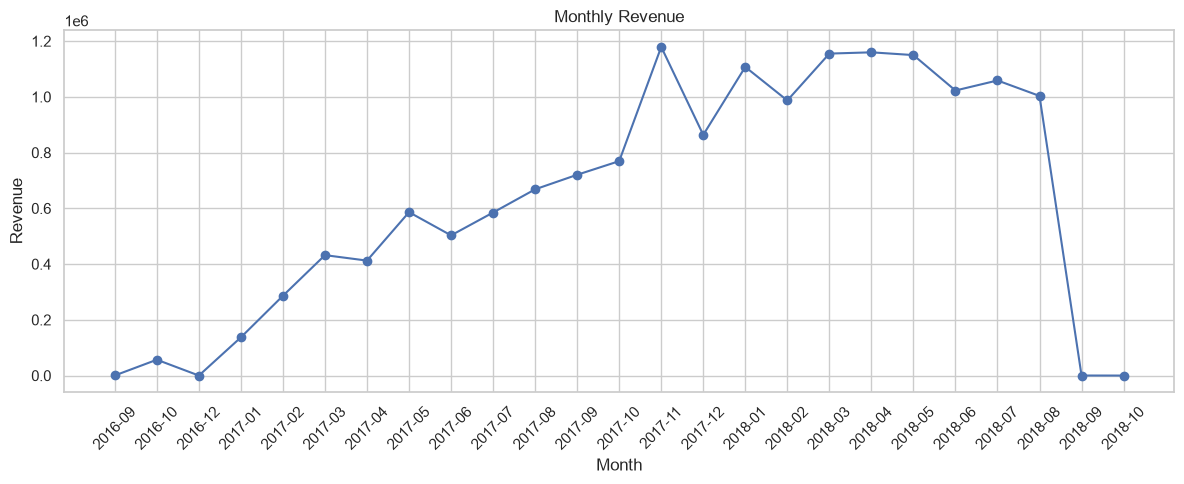

In [234]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")

plt.tight_layout()
plt.show()

In [235]:
category_revenue = (
    main_df.groupby("product_category_name_english")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

In [236]:
category_revenue.head(10)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: total_cost, dtype: float64

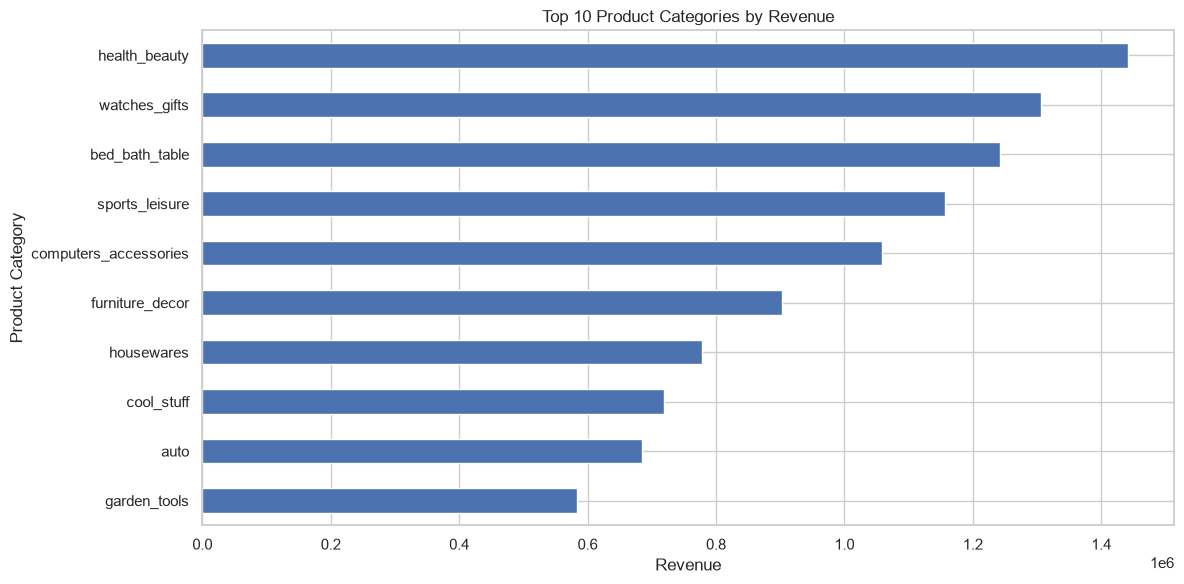

In [237]:
plt.figure(figsize=(12, 6))

category_revenue.head(10).sort_values().plot(kind="barh")

plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

plt.tight_layout()
plt.show()

In [238]:
print("Top category:")
print(category_revenue.index[0])

print("Revenue:")
print(category_revenue.iloc[0])

Top category:
health_beauty
Revenue:
1441248.07


In [239]:
category_sales = (
    main_df.groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
)

category_sales.head(10)

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
dtype: int64

In [240]:
state_customers = (
    main_df.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

In [241]:
state_customers

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
PE     1609
CE     1313
PA      949
MT      876
MA      726
MS      694
PB      519
PI      482
RN      474
AL      401
SE      342
TO      273
RO      240
AM      143
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64

In [242]:
state_customers.head(10)

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64

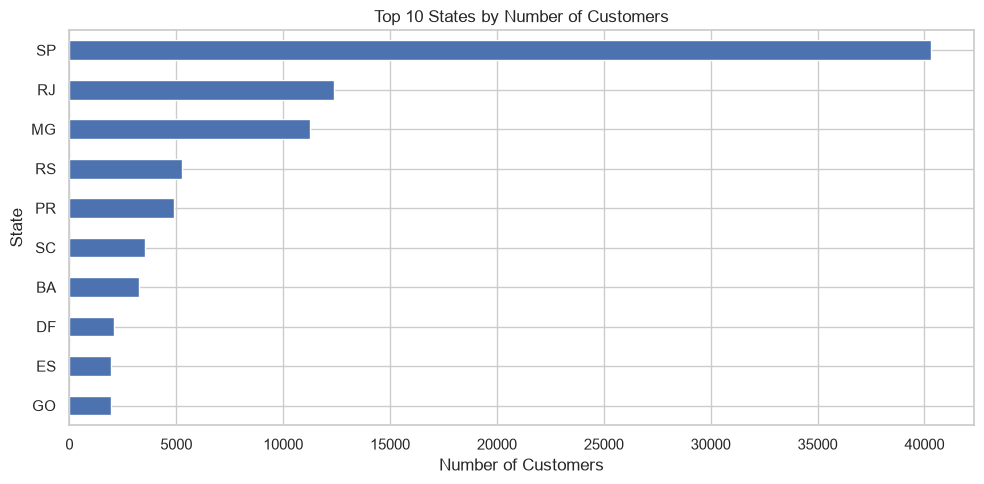

In [243]:
plt.figure(figsize=(10, 5))

state_customers.head(10).sort_values().plot(kind="barh")

plt.xlabel("Number of Customers")
plt.ylabel("State")
plt.title("Top 10 States by Number of Customers")

plt.tight_layout()
plt.show()

In [244]:
state_revenue = (
    main_df.groupby("customer_state")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

In [245]:
state_revenue.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: total_cost, dtype: float64

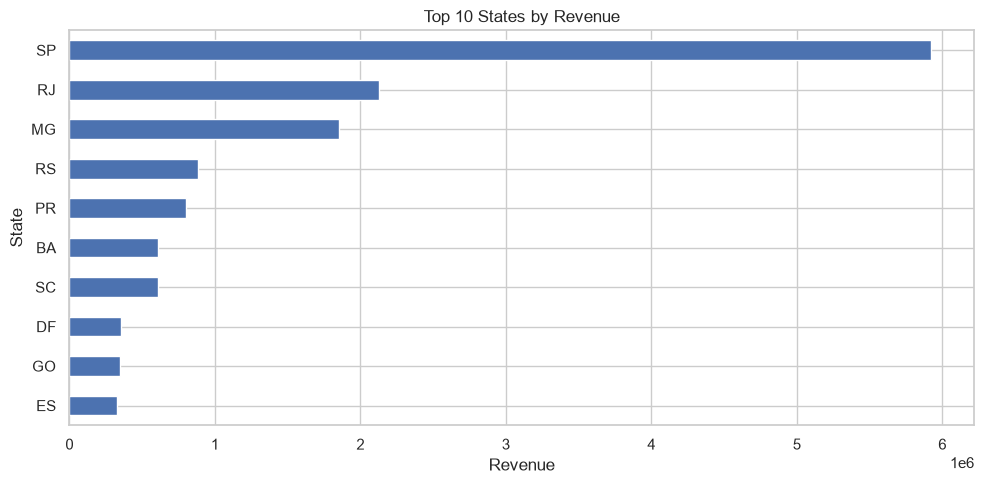

In [246]:
plt.figure(figsize=(10, 5))

state_revenue.head(10).sort_values().plot(kind="barh")

plt.xlabel("Revenue")
plt.ylabel("State")
plt.title("Top 10 States by Revenue")

plt.tight_layout()
plt.show()

In [247]:
payment_methods = payments["payment_type"].value_counts()

print(payment_methods)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


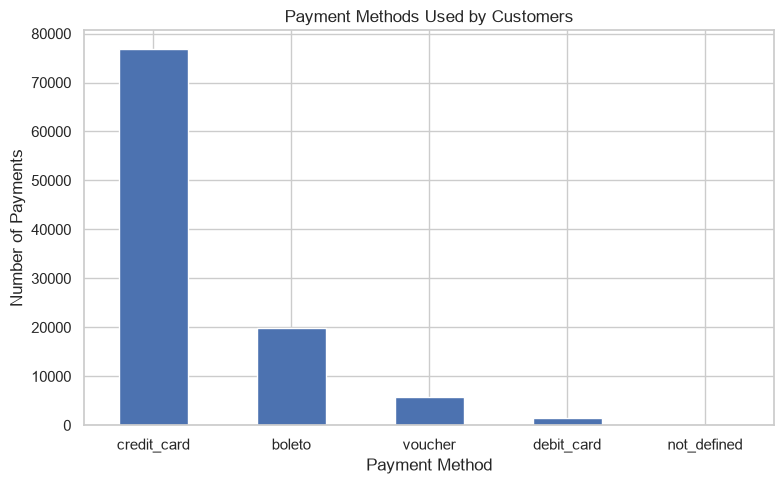

In [248]:
plt.figure(figsize=(8, 5))

payment_methods.plot(kind="bar")

plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")
plt.title("Payment Methods Used by Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [249]:
payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_revenue)

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64


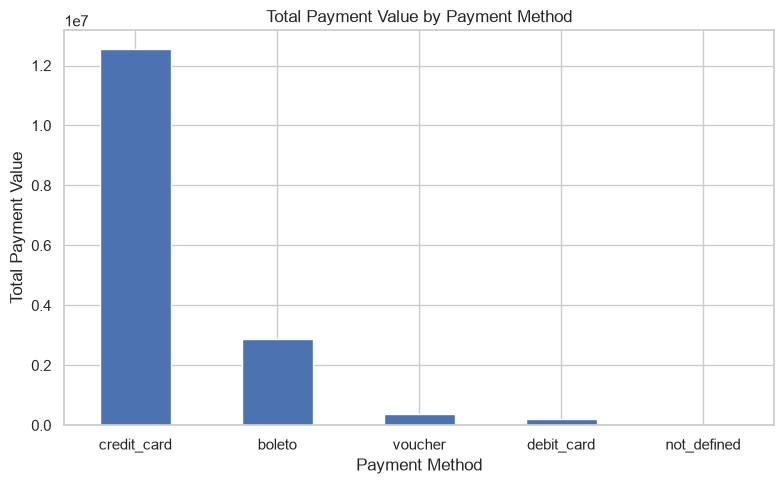

In [250]:
plt.figure(figsize=(8, 5))

payment_revenue.plot(kind="bar")

plt.xlabel("Payment Method")
plt.ylabel("Total Payment Value")
plt.title("Total Payment Value by Payment Method")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [251]:
payment_average = (
    payments.groupby("payment_type")["payment_value"]
    .mean()
    .sort_values(ascending=False)
)

print(payment_average)

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64


In [252]:
average_review = reviews["review_score"].mean()

print("Average Review Score:", average_review)

Average Review Score: 4.08642062404257


In [253]:
review_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

print(review_counts)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


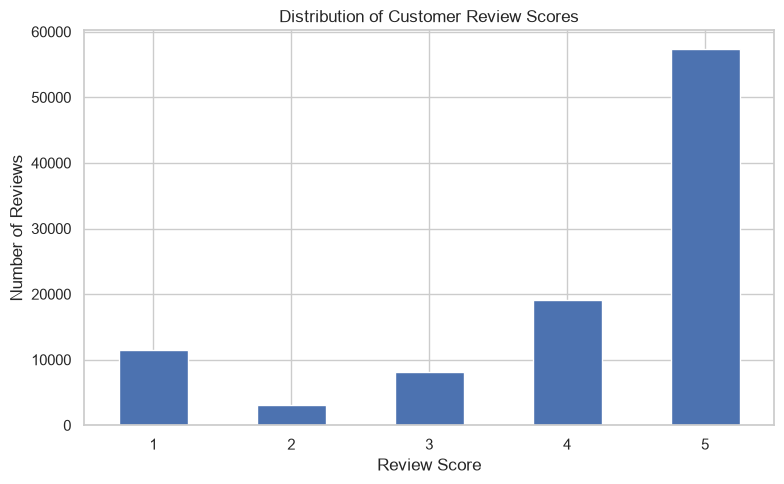

In [254]:
plt.figure(figsize=(8, 5))

review_counts.plot(kind="bar")

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Customer Review Scores")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [255]:
review_percentage = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(review_percentage)

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64


In [256]:
delay_review = (
    main_df.groupby("review_score")["delivery_delay_days"]
    .mean()
)

print(delay_review)

review_score
1.000000    -5.927227
1.500000    -9.166667
2.000000    -9.720492
2.500000   -10.390244
3.000000   -11.088034
3.333333   -14.000000
3.500000   -14.379310
4.000000   -12.478422
4.333333   -11.000000
4.500000   -12.656716
5.000000   -13.420803
Name: delivery_delay_days, dtype: float64


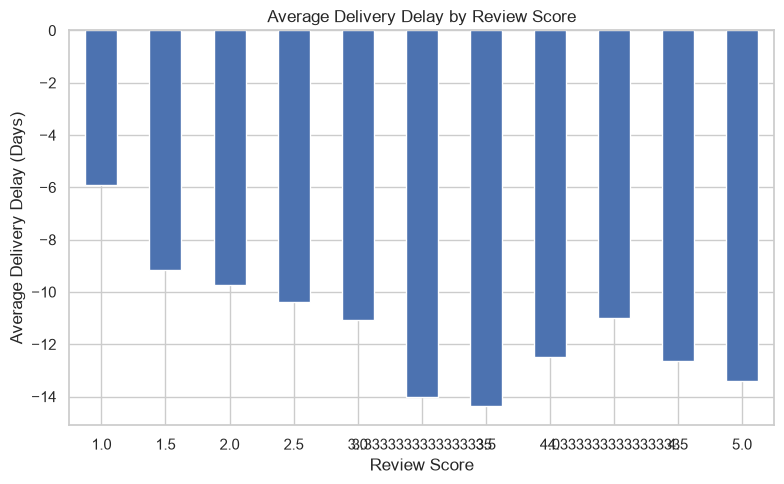

In [257]:
plt.figure(figsize=(8, 5))

delay_review.plot(kind="bar")

plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (Days)")
plt.title("Average Delivery Delay by Review Score")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [258]:
average_delivery = main_df["delivery_days"].mean()

print("Average Delivery Time:", average_delivery, "days")

Average Delivery Time: 12.007722603361284 days


In [259]:
main_df["delivery_days"].describe()

count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [260]:
def delivery_category(days):
    if pd.isna(days):
        return "Not Delivered"
    elif days <= 7:
        return "Fast"
    elif days <= 14:
        return "Normal"
    else:
        return "Slow"

main_df["delivery_category"] = main_df["delivery_days"].apply(
    delivery_category
)

In [261]:
main_df["delivery_category"].value_counts() 

delivery_category
Normal           41717
Fast             38723
Slow             29756
Not Delivered     3229
Name: count, dtype: int64

In [262]:
main_df["delivery_status"] = main_df["delivery_delay_days"].apply(
    lambda x: (
        "Not Delivered" if pd.isna(x)
        else "Late" if x > 0
        else "On Time"
    )
)

In [263]:
main_df["delivery_status"].value_counts()

delivery_status
On Time          102931
Late               7265
Not Delivered      3229
Name: count, dtype: int64

In [264]:
delivered = main_df[
    main_df["delivery_status"].isin(["Late", "On Time"])
]

late_percentage = (
    (delivered["delivery_status"] == "Late").mean() * 100
)

print("Late Order Percentage:", late_percentage)

Late Order Percentage: 6.592798286689172


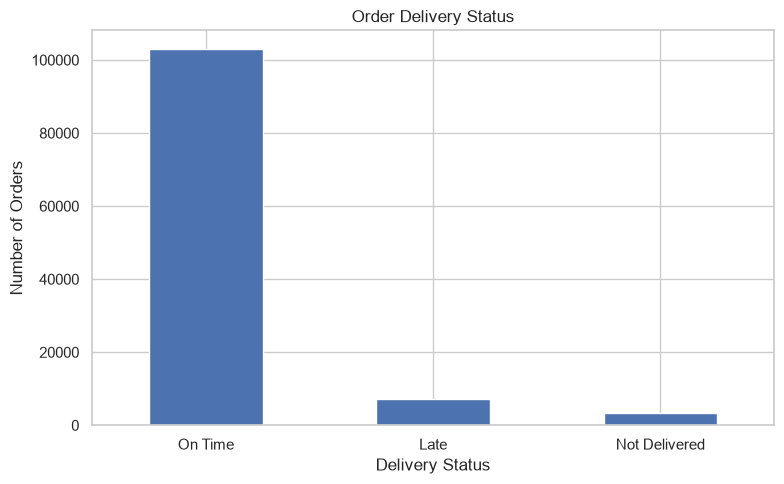

In [265]:
status_counts = main_df["delivery_status"].value_counts()

plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.title("Order Delivery Status")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [266]:
delivery_reviews = (
    main_df.groupby("delivery_status")["review_score"]
    .mean()
)

print(delivery_reviews)

delivery_status
Late             2.257411
Not Delivered    1.744750
On Time          4.208268
Name: review_score, dtype: float64


In [267]:
delivery_review_count = (
    main_df.groupby("delivery_status")["review_score"]
    .count()
)

print(delivery_review_count)

delivery_status
Late               7084
Not Delivered      3095
On Time          102285
Name: review_score, dtype: int64


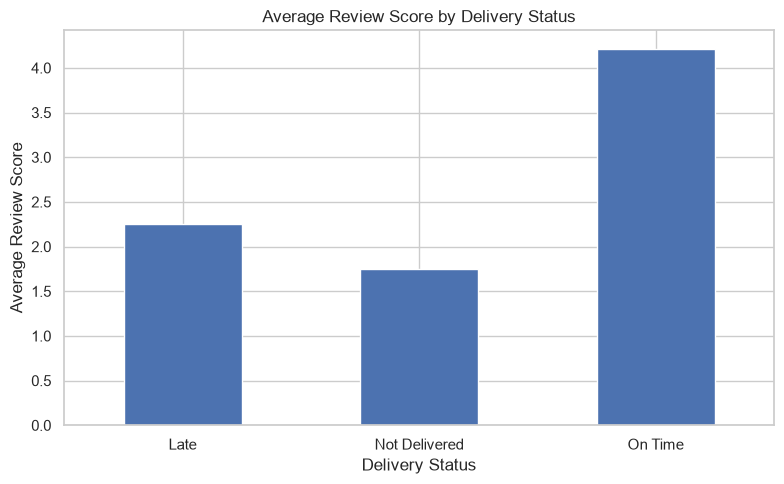

In [268]:
plt.figure(figsize=(8, 5))

delivery_reviews.plot(kind="bar")

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Delivery Status")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [269]:
product_revenue = (
    main_df.groupby("product_id")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

In [270]:
product_revenue.head(10)

product_id
bb50f2e236e5eea0100680137654686c    67606.10
d1c427060a0f73f6b889a5c7c61f2ac4    60976.03
6cdd53843498f92890544667809f1595    59093.99
99a4788cb24856965c36a24e339b6058    51071.60
d6160fb7873f184099d9bc95e30376af    50326.18
3dd2a17168ec895c781a9191c1e95ad7    48212.22
aca2eb7d00ea1a7b8ebd4e68314663af    44820.76
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
25c38557cf793876c5abdd5931f922db    40311.95
53b36df67ebb7c41585e8d54d6772e08    39957.93
Name: total_cost, dtype: float64

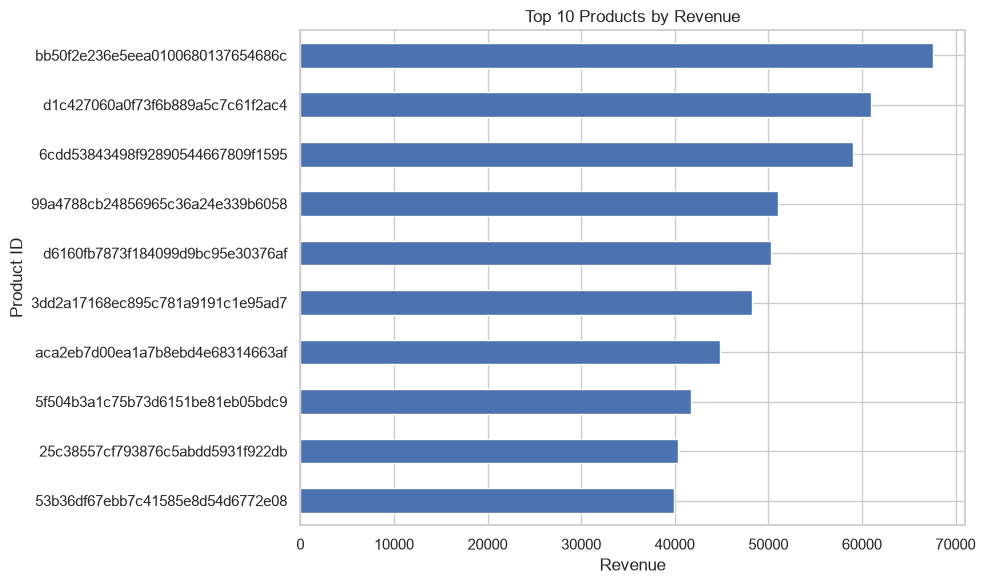

In [271]:
plt.figure(figsize=(10, 6))

product_revenue.head(10).sort_values().plot(kind="barh")

plt.xlabel("Revenue")
plt.ylabel("Product ID")
plt.title("Top 10 Products by Revenue")

plt.tight_layout()
plt.show()

In [272]:
product_sales = (
    main_df.groupby("product_id")
    .size()
    .sort_values(ascending=False)
)

product_sales.head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
dtype: int64

In [273]:
seller_revenue = (
    main_df.groupby("seller_id")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

In [274]:
seller_revenue.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: total_cost, dtype: float64

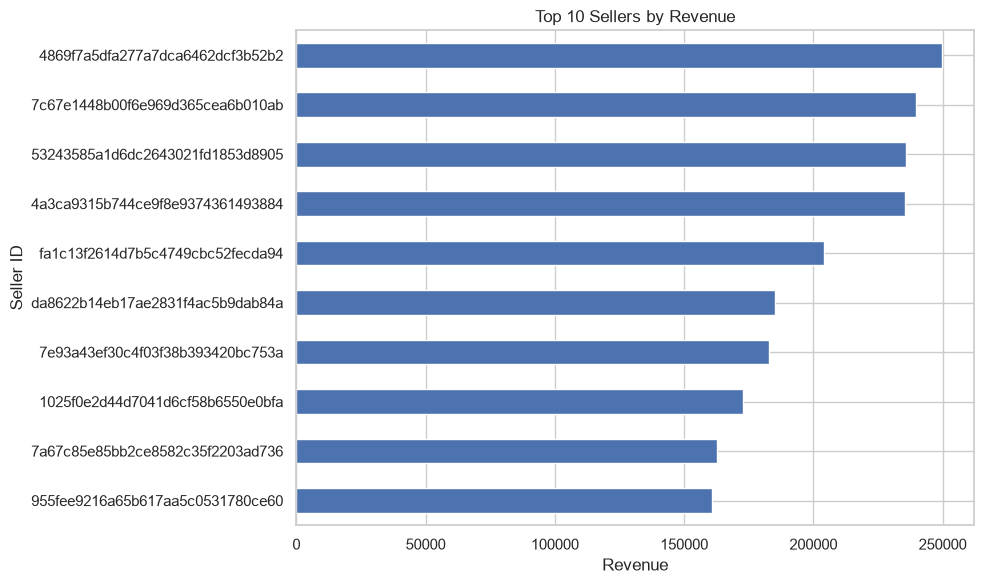

In [275]:
plt.figure(figsize=(10, 6))

seller_revenue.head(10).sort_values().plot(kind="barh")

plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.title("Top 10 Sellers by Revenue")

plt.tight_layout()
plt.show()

In [276]:
seller_sales = (
    main_df.groupby("seller_id")
    .size()
    .sort_values(ascending=False)
)

seller_sales.head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
dtype: int64

In [277]:
seller_average = (
    main_df.groupby("seller_id")["total_cost"]
    .mean()
    .sort_values(ascending=False)
)

seller_average.head(10)

seller_id
80ceebb4ee9b31afb6c6a916a574a1e2    6922.210
ee27a8f15b1dded4d213a468ba4eb391    6726.660
585175ec331ea177fa47199e39a6170a    3602.470
abe021b01ba992245271b9aa422032df    3418.620
a00824eb9093d40e589b940ec45c4eb0    3259.820
e2a1ac9bf33e5549a2a4f834e70df2f8    3040.112
e908c0f3646e8b60375734a350d95d71    3009.530
d63c73efd41eb002280e7ec831424edb    2883.295
1444c08e64d55fb3c25f0f09c07ffcf2    2818.740
039e6ad9dae79614493083e241147386    2654.684
Name: total_cost, dtype: float64

In [278]:
city_customers = (
    main_df.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

In [279]:
city_customers.head(10)

customer_city
sao paulo                14984
rio de janeiro            6620
belo horizonte            2672
brasilia                  2069
curitiba                  1465
campinas                  1398
porto alegre              1326
salvador                  1209
guarulhos                 1153
sao bernardo do campo      908
Name: customer_unique_id, dtype: int64

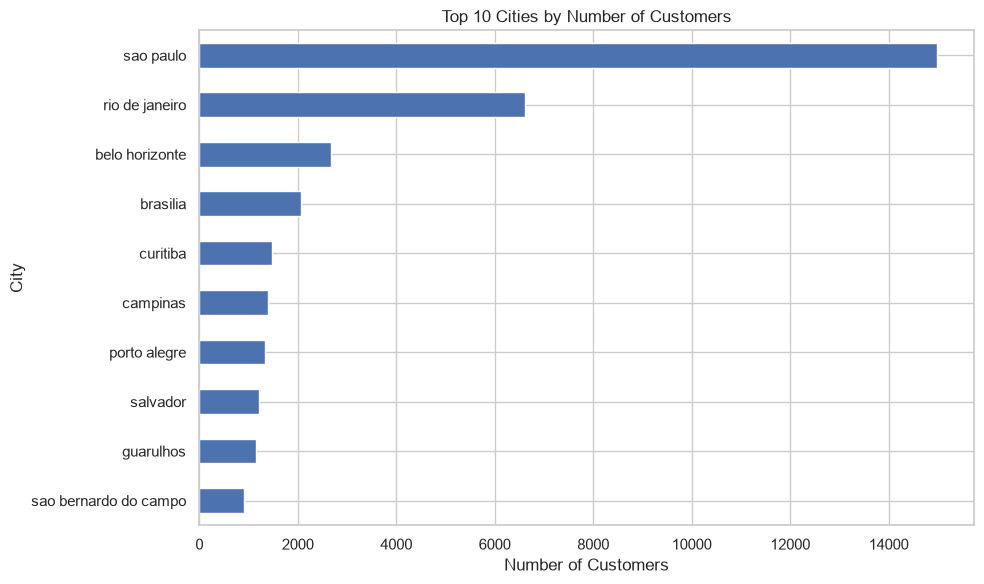

In [280]:
plt.figure(figsize=(10, 6))

city_customers.head(10).sort_values().plot(kind="barh")

plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.title("Top 10 Cities by Number of Customers")

plt.tight_layout()
plt.show()

In [281]:
city_revenue = (
    main_df.groupby("customer_city")["total_cost"]
    .sum()
    .sort_values(ascending=False)
)

In [282]:
city_revenue.head(10)

customer_city
sao paulo         2170227.12
rio de janeiro    1154234.02
belo horizonte     416733.39
brasilia           352305.14
curitiba           244739.87
porto alegre       224064.09
salvador           216772.40
campinas           212541.70
guarulhos          163575.82
niteroi            137919.38
Name: total_cost, dtype: float64

In [283]:
print("Total Revenue:", main_df["total_cost"].sum())
print("Total Orders:", main_df["order_id"].nunique())
print("Total Customers:", main_df["customer_unique_id"].nunique())
print("Average Delivery Days:", main_df["delivery_days"].mean())
print("Average Review Score:", main_df["review_score"].mean())

Total Revenue: 15843553.24
Total Orders: 99441
Total Customers: 96096
Average Delivery Days: 12.007722603361284
Average Review Score: 4.0175893322900365


In [284]:
print("Top Revenue Category:")
print(category_revenue.head(1))

Top Revenue Category:
product_category_name_english
health_beauty    1441248.07
Name: total_cost, dtype: float64


In [285]:
print("Top State by Revenue:")
print(state_revenue.head(1))

Top State by Revenue:
customer_state
SP    5921678.12
Name: total_cost, dtype: float64


In [286]:
print("Most Used Payment Method:")
print(payment_methods.head(1))

Most Used Payment Method:
payment_type
credit_card    76795
Name: count, dtype: int64


In [287]:
print("Late Delivery %:", late_percentage)

Late Delivery %: 6.592798286689172


In [288]:
print(delivery_reviews)

delivery_status
Late             2.257411
Not Delivered    1.744750
On Time          4.208268
Name: review_score, dtype: float64


In [289]:
insights = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Delivery Days",
        "Average Review Score",
        "Late Delivery %",
        "Top Category",
        "Top State",
        "Most Used Payment Method"
    ],
    "Value": [
        main_df["total_cost"].sum(),
        main_df["order_id"].nunique(),
        main_df["customer_unique_id"].nunique(),
        main_df["delivery_days"].mean(),
        main_df["review_score"].mean(),
        late_percentage,
        category_revenue.index[0],
        state_revenue.index[0],
        payment_methods.index[0]
    ]
})

insights

,Metric,Value
0,Total Revenue,15843553.24
1,Total Orders,99441
2,Total Customers,96096
3,Average Delivery Days,12.007723
4,Average Review Score,4.017589
5,Late Delivery %,6.592798
6,Top Category,health_beauty
7,Top State,SP
8,Most Used Payment Method,credit_card


In [290]:
kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Delivery Days",
        "Average Review Score",
        "Late Delivery %"
    ],
    "Value": [
        main_df["total_cost"].sum(),
        main_df["order_id"].nunique(),
        main_df["customer_unique_id"].nunique(),
        main_df.groupby("order_id")["total_cost"].sum().mean(),
        main_df["delivery_days"].mean(),
        main_df["review_score"].mean(),
        late_percentage
    ]
})

kpi

,KPI,Value
0,Total Revenue,1.584355e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.593262e+02
4,Average Delivery Days,1.200772e+01
5,Average Review Score,4.017589e+00
6,Late Delivery %,6.592798e+00


In [291]:
kpi["Value"] = kpi["Value"].round(2)

kpi

,KPI,Value
0,Total Revenue,15843553.24
1,Total Orders,99441.00
2,Total Customers,96096.00
3,Average Order Value,159.33
4,Average Delivery Days,12.01
5,Average Review Score,4.02
6,Late Delivery %,6.59


In [292]:
main_df.to_csv("olist_main_dataset.csv", index=False)

In [293]:
kpi.to_csv("olist_kpis.csv", index=False)

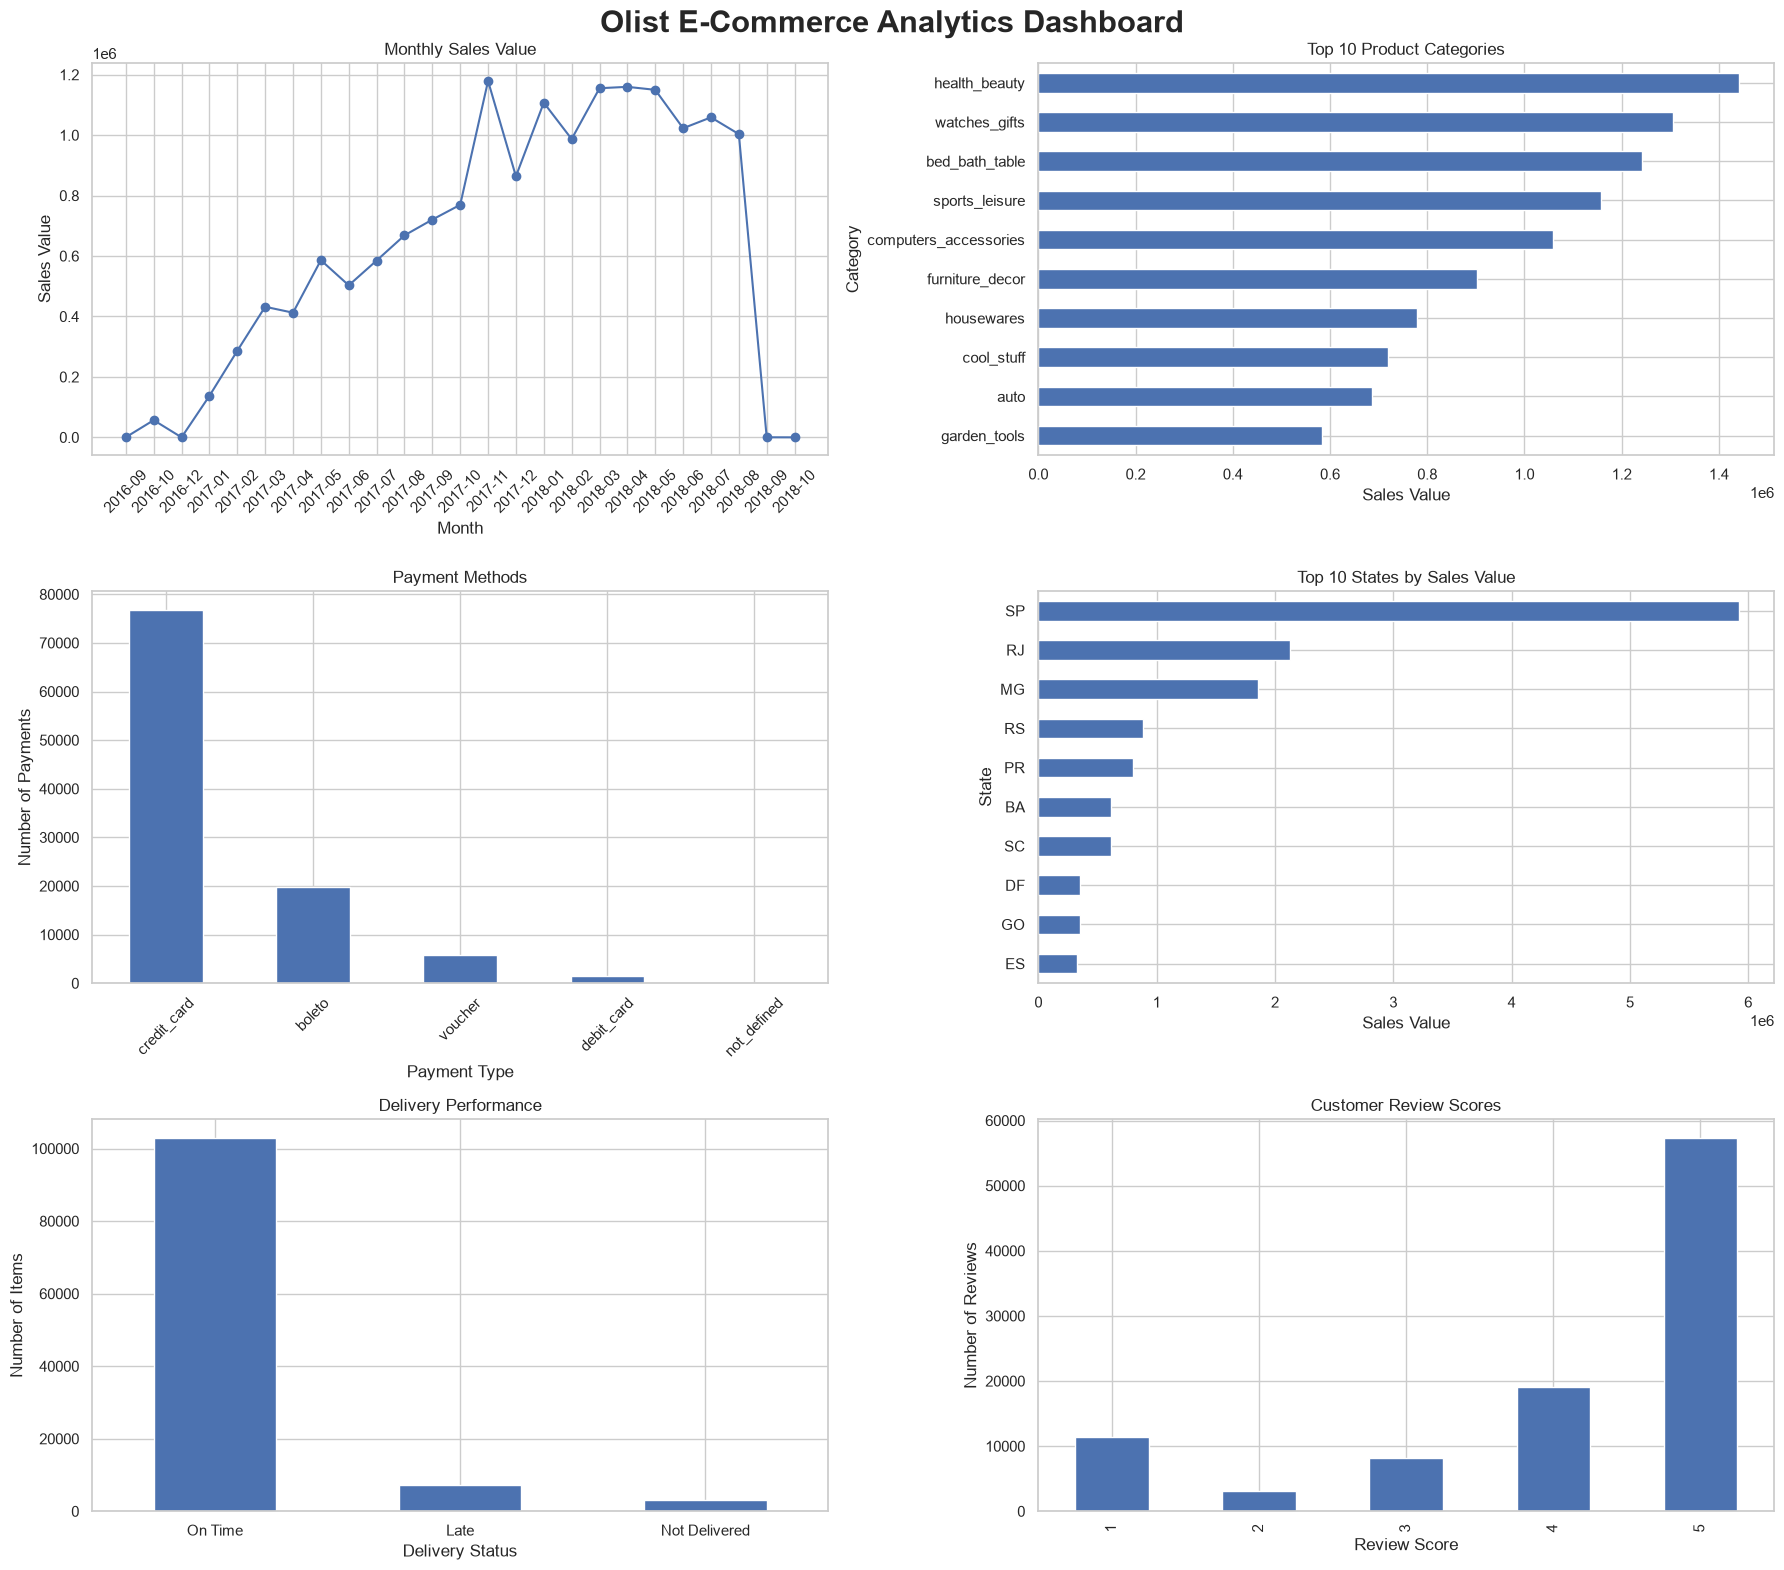

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

fig.suptitle(
    "Olist E-Commerce Analytics Dashboard",
    fontsize=22,
    fontweight="bold"
)

# -----------------------------
# 1. Monthly Revenue
# -----------------------------
axes[0, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

axes[0, 0].set_title("Monthly Sales Value")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Sales Value")
axes[0, 0].tick_params(axis="x", rotation=45)


# -----------------------------
# 2. Top 10 Categories
# -----------------------------
category_revenue.head(10).sort_values().plot(
    kind="barh",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Top 10 Product Categories")
axes[0, 1].set_xlabel("Sales Value")
axes[0, 1].set_ylabel("Category")


# -----------------------------
# 3. Payment Methods
# -----------------------------
payment_methods.plot(
    kind="bar",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Payment Methods")
axes[1, 0].set_xlabel("Payment Type")
axes[1, 0].set_ylabel("Number of Payments")

axes[1, 0].tick_params(axis="x", rotation=45)


# -----------------------------
# 4. Top 10 States
# -----------------------------
state_revenue.head(10).sort_values().plot(
    kind="barh",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Top 10 States by Sales Value")
axes[1, 1].set_xlabel("Sales Value")
axes[1, 1].set_ylabel("State")


# -----------------------------
# 5. Delivery Status
# -----------------------------
delivery_status_counts = (
    main_df["delivery_status"]
    .value_counts()
)

delivery_status_counts.plot(
    kind="bar",
    ax=axes[2, 0]
)

axes[2, 0].set_title("Delivery Performance")
axes[2, 0].set_xlabel("Delivery Status")
axes[2, 0].set_ylabel("Number of Items")

axes[2, 0].tick_params(axis="x", rotation=0)


# -----------------------------
# 6. Review Scores
# -----------------------------
review_counts.plot(
    kind="bar",
    ax=axes[2, 1]
)

axes[2, 1].set_title("Customer Review Scores")
axes[2, 1].set_xlabel("Review Score")
axes[2, 1].set_ylabel("Number of Reviews")


plt.tight_layout()
plt.show()

In [295]:
print("========== OLIST KPI SUMMARY ==========")

print("Total Sales Value:", round(main_df["total_cost"].sum(), 2))
print("Total Orders:", main_df["order_id"].nunique())
print("Total Customers:", main_df["customer_unique_id"].nunique())
print("Average Order Value:", round(
    main_df.groupby("order_id")["total_cost"].sum().mean(), 2
))
print("Average Delivery Days:", round(
    main_df["delivery_days"].mean(), 2
))
print("Average Review Score:", round(
    main_df["review_score"].mean(), 2
))
print("Late Delivery %:", round(late_percentage, 2))

========== OLIST KPI SUMMARY ==========
Total Sales Value: 15843553.24
Total Orders: 99441
Total Customers: 96096
Average Order Value: 159.33
Average Delivery Days: 12.01
Average Review Score: 4.02
Late Delivery %: 6.59
